# Phase 1C: Dataset Integration and Feature Engineering

## Objective

Combine the processed road complaint, weather, and traffic datasets into a monthly street-level machine-learning dataset. The final target predicts whether a street will receive at least two complaints in the next calendar month.

## 1. Import Libraries and Load Processed Data

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

road_complaints = pd.read_csv("../data/processed/road_complaints.csv")
weather = pd.read_csv("../data/processed/weather.csv")
traffic = pd.read_csv("../data/processed/traffic.csv")

print("Road complaints:", road_complaints.shape)
print("Weather:", weather.shape)
print("Traffic:", traffic.shape)


Road complaints: (1183771, 22)
Weather: (5114, 6)
Traffic: (19850, 4)


## 2. Prepare Dates and Street Names

In [47]:
# Convert date columns

road_complaints["Created Date"] = pd.to_datetime(
    road_complaints["Created Date"],
    errors="coerce"
)

weather["Date"] = pd.to_datetime(
    weather["Date"],
    errors="coerce"
)

traffic["Date"] = pd.to_datetime(
    traffic["Date"],
    errors="coerce"
)

# Create Year and Month columns

road_complaints["Year"] = road_complaints["Created Date"].dt.year
road_complaints["Month"] = road_complaints["Created Date"].dt.month

weather["Year"] = weather["Date"].dt.year
weather["Month"] = weather["Date"].dt.month

traffic["Year"] = traffic["Date"].dt.year
traffic["Month"] = traffic["Date"].dt.month

print("Weather columns:", weather.columns.tolist())

Weather columns: ['Date', 'Avg_Temperature', 'Total_Precipitation', 'Total_Snowfall', 'Avg_Snow_Depth', 'Avg_Wind_Speed', 'Year', 'Month']


## 3. Create Monthly Weather Features

In [48]:
monthly_weather = (
    weather
    .groupby(["Year", "Month"], as_index=False)
    .agg(
        Avg_Temperature=("Avg_Temperature", "mean"),
        Total_Precipitation=("Total_Precipitation", "sum"),
        Total_Snowfall=("Total_Snowfall", "sum"),
        Avg_Snow_Depth=("Avg_Snow_Depth", "mean"),
        Avg_Wind_Speed=("Avg_Wind_Speed", "mean")
    )
)

monthly_weather.head()

,Year,Month,Avg_Temperature,Total_Precipitation,Total_Snowfall,Avg_Snow_Depth,Avg_Wind_Speed
0,2012,1,34.627285,2.662,3.614,0.025009,8.023253
1,2012,2,37.570690,1.366,1.658,0.011710,7.342529
2,2012,3,47.683333,1.377,0.000,0.000000,7.317876
3,2012,4,52.821667,1.897,0.000,0.000000,8.102917
4,2012,5,63.464516,3.738,0.000,0.000000,5.809140


## 4. Create Monthly Traffic Features

In [49]:
monthly_traffic = (
    traffic
    .groupby(
        ["Street Name", "Year", "Month"],
        as_index=False
    )
    .agg(
        Avg_Daily_Traffic=("Daily_Traffic_Volume", "mean"),
        Traffic_Observation_Days=("Traffic_Records", "sum")
    )
)

monthly_traffic.head()


,Street Name,Year,Month,Avg_Daily_Traffic,Traffic_Observation_Days
0,1 AVE,2012,9,11971.000000,2
1,1 AVE,2012,10,7402.357143,14
2,1 AVENUE,2012,9,5175.500000,2
3,1 AVENUE,2012,10,6208.722222,36
4,1 AVENUE,2015,10,10101.000000,18


## 5. Count Observed Monthly Road Complaints


In [50]:
monthly_complaints = (
    road_complaints
    .groupby(
        ["Street Name", "Borough", "Year", "Month"],
        as_index=False
    )
    .agg(
        Complaint_Count=("Unique Key", "count"),
        Latitude=("Latitude", "mean"),
        Longitude=("Longitude", "mean")
    )
)

monthly_complaints["Date"] = pd.to_datetime(
    dict(
        year=monthly_complaints["Year"],
        month=monthly_complaints["Month"],
        day=1
    )
)

monthly_complaints.head()

,Street Name,Borough,Year,Month,Complaint_Count,Latitude,Longitude,Date
0,0CEAN AVENUE,BROOKLYN,2013,8,1,NaN,NaN,2013-08-01
1,1 AVE,MANHATTAN,2012,10,1,NaN,NaN,2012-10-01
2,1 AVE,MANHATTAN,2014,7,1,NaN,NaN,2014-07-01
3,1 AVE,MANHATTAN,2019,3,1,NaN,NaN,2019-03-01
4,1 AVE,UNSPECIFIED,2018,6,1,NaN,NaN,2018-06-01


## 6. Complete Each Street's Monthly Timeline

Months without a complaint are added with `Complaint_Count = 0`. This ensures that shifting the target by one row truly represents the next calendar month.

In [51]:
def complete_monthly_timeline(group):
    street_name, borough = group.name
    group = group.sort_values("Date").copy()

    full_dates = pd.date_range(
        start=group["Date"].min(),
        end=group["Date"].max(),
        freq="MS"
    )

    group = (
        group
        .set_index("Date")
        .reindex(full_dates)
        .rename_axis("Date")
        .reset_index()
    )

    group["Street Name"] = street_name
    group["Borough"] = borough

    group["Latitude"] = group["Latitude"].ffill().bfill()
    group["Longitude"] = group["Longitude"].ffill().bfill()
    group["Complaint_Count"] = group["Complaint_Count"].fillna(0)

    group["Year"] = group["Date"].dt.year
    group["Month"] = group["Date"].dt.month

    return group


monthly_complaints_complete = (
    monthly_complaints
    .groupby(
        ["Street Name", "Borough"],
        group_keys=False
    )
    .apply(
        complete_monthly_timeline,
        include_groups=False
    )
    .reset_index(drop=True)
)

print("Observed monthly rows:", monthly_complaints.shape[0])
print("Completed monthly rows:", monthly_complaints_complete.shape[0])

Observed monthly rows: 311796
Completed monthly rows: 1154460


## 7. Validate the Completed Timeline


In [52]:
timeline_check = (
    monthly_complaints_complete
    .sort_values(["Street Name", "Borough", "Date"])
    .groupby(["Street Name", "Borough"])["Date"]
    .diff()
    .dropna()
)

print("Non-monthly gaps:", (timeline_check.dt.days < 28).sum() + (timeline_check.dt.days > 31).sum())

display(
    monthly_complaints_complete[
        (monthly_complaints_complete["Street Name"] == "1 AVENUE") &
        (monthly_complaints_complete["Borough"] == "BROOKLYN")
    ][
        ["Street Name", "Borough", "Date", "Complaint_Count"]
    ].head(20)
)

Non-monthly gaps: 0


,Street Name,Borough,Date,Complaint_Count
80,1 AVENUE,BROOKLYN,2012-01-01,3.0
81,1 AVENUE,BROOKLYN,2012-02-01,0.0
82,1 AVENUE,BROOKLYN,2012-03-01,3.0
83,1 AVENUE,BROOKLYN,2012-04-01,3.0
84,1 AVENUE,BROOKLYN,2012-05-01,1.0
85,1 AVENUE,BROOKLYN,2012-06-01,3.0
86,1 AVENUE,BROOKLYN,2012-07-01,5.0
87,1 AVENUE,BROOKLYN,2012-08-01,1.0
88,1 AVENUE,BROOKLYN,2012-09-01,4.0
89,1 AVENUE,BROOKLYN,2012-10-01,0.0


## 8. Merge Weather and Traffic Features


In [53]:
model_data = monthly_complaints_complete.merge(
    monthly_weather,
    on=["Year", "Month"],
    how="left",
    validate="many_to_one"
)

model_data = model_data.merge(
    monthly_traffic,
    on=["Street Name", "Year", "Month"],
    how="left",
    validate="many_to_one"
)

print("Merged dataset:", model_data.shape)

Merged dataset: (1154460, 15)


## 9. Handle Missing Traffic and Check Merge Quality


In [54]:
model_data["Traffic_Data_Available"] = (
    model_data["Avg_Daily_Traffic"].notna().astype(int)
)

model_data["Avg_Daily_Traffic"] = (
    model_data["Avg_Daily_Traffic"].fillna(0)
)

model_data["Traffic_Observation_Days"] = (
    model_data["Traffic_Observation_Days"].fillna(0)
)

print("Missing weather values:")
display(
    model_data[
        [
            "Avg_Temperature",
            "Total_Precipitation",
            "Total_Snowfall",
            "Avg_Snow_Depth",
            "Avg_Wind_Speed"
        ]
    ].isna().sum()
)

print(
    "Traffic coverage:",
    round(model_data["Traffic_Data_Available"].mean() * 100, 2),
    "%"
)

Missing weather values:


Avg_Temperature        0
Total_Precipitation    0
Total_Snowfall         0
Avg_Snow_Depth         0
Avg_Wind_Speed         0
dtype: int64

Traffic coverage: 0.29 %


## 10. Create Historical Features and the Future Target

In [55]:
model_data = model_data.sort_values(
    ["Street Name", "Borough", "Date"]
).reset_index(drop=True)

street_groups = model_data.groupby(
    ["Street Name", "Borough"]
)["Complaint_Count"]

model_data["Previous_Month_Complaints"] = street_groups.shift(1)

model_data["Complaints_Last_3_Months"] = (
    model_data
    .groupby(["Street Name", "Borough"])["Complaint_Count"]
    .transform(
        lambda values: values.shift(1).rolling(
            window=3,
            min_periods=1
        ).sum()
    )
)

model_data["Average_Complaints_Last_3_Months"] = (
    model_data
    .groupby(["Street Name", "Borough"])["Complaint_Count"]
    .transform(
        lambda values: values.shift(1).rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

model_data["Complaints_Last_6_Months"] = (
    model_data
    .groupby(["Street Name", "Borough"])["Complaint_Count"]
    .transform(
        lambda values: values.shift(1).rolling(
            window=6,
            min_periods=1
        ).sum()
    )
)

model_data["Next_Month_Complaint_Count"] = street_groups.shift(-1)


## 11. Remove Rows Without a Future Month and Create the Target


In [56]:
model_data = model_data.dropna(
    subset=["Next_Month_Complaint_Count"]
).reset_index(drop=True)

model_data["Maintenance_Risk"] = (
    model_data["Next_Month_Complaint_Count"] >= 2
).astype(int)

print("Final rows:", model_data.shape[0])
display(model_data["Maintenance_Risk"].value_counts())
display(model_data["Maintenance_Risk"].value_counts(normalize=True) * 100)


Final rows: 1141808


Maintenance_Risk
0    992769
1    149039
Name: count, dtype: int64

Maintenance_Risk
0    86.947105
1    13.052895
Name: proportion, dtype: float64

## 12. Inspect the Future Complaint Distribution

count    1.141808e+06
mean     7.073273e-01
std      2.317244e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      2.620000e+02
Name: Next_Month_Complaint_Count, dtype: float64

Next_Month_Complaint_Count
0.0     842664
1.0     150105
2.0      60654
3.0      30523
4.0      17221
5.0      10900
6.0       7245
7.0       5032
8.0       3511
9.0       2634
10.0      1983
11.0      1522
12.0      1191
13.0       982
14.0       777
15.0       637
16.0       574
17.0       452
18.0       390
19.0       303
Name: count, dtype: int64

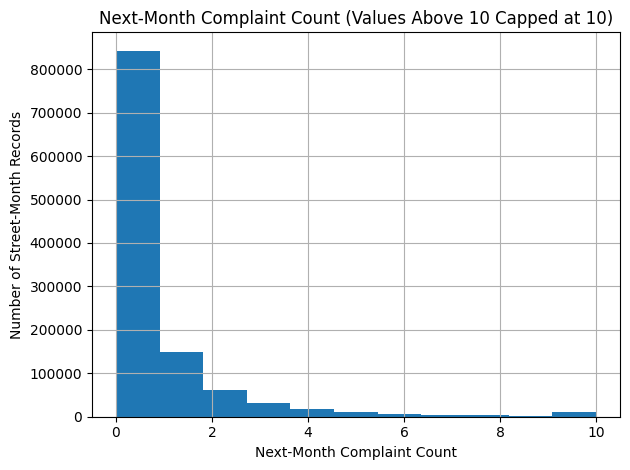

In [58]:
display(model_data["Next_Month_Complaint_Count"].describe())
display(model_data["Next_Month_Complaint_Count"].value_counts().head(20))

model_data["Next_Month_Complaint_Count"].clip(upper=10).hist(
    bins=11
)

plt.title("Next-Month Complaint Count (Values Above 10 Capped at 10)")
plt.xlabel("Next-Month Complaint Count")
plt.ylabel("Number of Street-Month Records")
plt.tight_layout()
plt.show()

## 13. Final Validation


In [59]:
print("Duplicate street-month rows:", model_data.duplicated(
    subset=["Street Name", "Borough", "Date"]
).sum())

print("Missing target values:", model_data["Maintenance_Risk"].isna().sum())

print("Date range:", model_data["Date"].min(), "to", model_data["Date"].max())

display(
    model_data[
        [
            "Street Name",
            "Borough",
            "Date",
            "Complaint_Count",
            "Previous_Month_Complaints",
            "Complaints_Last_3_Months",
            "Complaints_Last_6_Months",
            "Next_Month_Complaint_Count",
            "Maintenance_Risk"
        ]
    ].head(20)
)


Duplicate street-month rows: 0
Missing target values: 0
Date range: 2012-01-01 00:00:00 to 2025-11-01 00:00:00


,Street Name,Borough,Date,Complaint_Count,Previous_Month_Complaints,Complaints_Last_3_Months,Complaints_Last_6_Months,Next_Month_Complaint_Count,Maintenance_Risk
0,1 AVE,MANHATTAN,2012-10-01,1.0,NaN,NaN,NaN,0.0,0
1,1 AVE,MANHATTAN,2012-11-01,0.0,1.0,1.0,1.0,0.0,0
2,1 AVE,MANHATTAN,2012-12-01,0.0,0.0,1.0,1.0,0.0,0
3,1 AVE,MANHATTAN,2013-01-01,0.0,0.0,1.0,1.0,0.0,0
4,1 AVE,MANHATTAN,2013-02-01,0.0,0.0,0.0,1.0,0.0,0
5,1 AVE,MANHATTAN,2013-03-01,0.0,0.0,0.0,1.0,0.0,0
6,1 AVE,MANHATTAN,2013-04-01,0.0,0.0,0.0,1.0,0.0,0
7,1 AVE,MANHATTAN,2013-05-01,0.0,0.0,0.0,0.0,0.0,0
8,1 AVE,MANHATTAN,2013-06-01,0.0,0.0,0.0,0.0,0.0,0
9,1 AVE,MANHATTAN,2013-07-01,0.0,0.0,0.0,0.0,0.0,0


## 14. Save the Engineered Dataset


In [60]:
model_data.to_csv(
    "../data/processed/model_data.csv",
    index=False
)

print("Feature engineering complete.")
print("Saved shape:", model_data.shape)

Feature engineering complete.
Saved shape: (1141808, 22)


## Phase 1C Summary

The processed complaint, weather, and traffic datasets were combined into a monthly street-level dataset. Missing street-months were explicitly added with zero complaints, ensuring that the target represents the next calendar month rather than the next available complaint record. Historical complaint features use only earlier months, while the target identifies streets expected to receive at least two complaints in the following month. Merge validation and final data-quality checks were added before saving the dataset for model training.
